# Volatility Modeling with GARCH-family + Google Trends (SVI)

## Scope of this notebook (current step)

In this step, we implement:
1. Setup and data split (chronological 80/20).
2. **Phase 1: Preliminary testing on Train data only**:
   - Jarque-Bera normality test on `return`.
   - ADF stationarity tests on `return`, `SVI`, `SVI_pos`, `SVI_neg`.
   - Stationarity guard for exogenous variables: if non-stationary, use first difference and recreate lagged exogenous variables.
   - ARCH-LM test on residuals from a constant-mean equation.

### Critical constraints enforced
- GARCH model target later will be `return` (not `target`).
- Exogenous variables for modeling later will be **lagged only**.
- Train/Test leakage is avoided in testing decisions (all statistical tests in Phase 1 use Train only).

In [12]:
# =========================
# Setup
# =========================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Reproducibility / numerical constants
RANDOM_STATE = 42
EPS = 1e-10

DATA_PATH = Path("data/final_data.csv")
REQUIRED_COLS = ["return", "target", "SVI", "SVI_pos", "SVI_neg"]


def decision_text(p_value: float, alpha: float = 0.05) -> str:
    """Return textual decision for hypothesis tests."""
    return "Reject H0" if p_value < alpha else "Fail to reject H0"

In [13]:
# =========================
# Data loading and chronological split (80/20)
# =========================

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()

missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

split_idx = int(len(df) * 0.8)
train_raw = df.iloc[:split_idx].copy()
test_raw = df.iloc[split_idx:].copy()

print(f"Total observations: {len(df):,}")
print(f"Train observations (80%): {len(train_raw):,} | {train_raw.index.min().date()} -> {train_raw.index.max().date()}")
print(f"Test observations  (20%): {len(test_raw):,} | {test_raw.index.min().date()} -> {test_raw.index.max().date()}")

train_raw[["return", "target", "SVI", "SVI_pos", "SVI_neg"]].head()

Total observations: 3,992
Train observations (80%): 3,193 | 2010-01-05 -> 2022-10-20
Test observations  (20%): 799 | 2022-10-21 -> 2025-12-31


,return,target,SVI,SVI_pos,SVI_neg
date,,,,,
2010-01-05,2.934662,8.612240,4.986535,14.633793,-0.000000
2010-01-06,0.374883,0.140537,6.631942,2.486204,-0.000000
2010-01-07,-0.224761,0.050518,6.720395,0.000000,1.510485
2010-01-08,-2.352603,5.534742,6.871988,0.000000,16.167061
2010-01-11,-1.119703,1.253734,4.530968,0.000000,5.073338


## Phase 1 - Preliminary Testing (Train data only)

All tests in this section are performed strictly on `train_raw` to avoid data leakage.

In [ ]:
# 1) Normality test on train return: Jarque-Bera
jb_stat, jb_pvalue = jarque_bera(train_raw["return"].dropna())

print("Jarque-Bera test on TRAIN return")
print(f"JB statistic: {jb_stat:,.4f}")
print(f"p-value:      {jb_pvalue:.6g}")

if jb_pvalue < 0.05:
    print("Conclusion: Reject normality (return distribution is non-normal / fat-tailed).")
else:
    print("Conclusion: Fail to reject normality.")

Jarque-Bera test on TRAIN return
JB statistic: 1,760.6201
p-value:      0
Conclusion: Reject normality (return distribution is non-normal / fat-tailed).


In [ ]:
# 2) ADF stationarity tests on train data only


def run_adf(series: pd.Series, name: str, alpha: float = 0.05) -> dict:
    series = series.dropna()
    stat, pval, used_lag, nobs, _, _ = adfuller(series, autolag="AIC")
    return {
        "variable": name,
        "adf_stat": stat,
        "p_value": pval,
        "used_lag": used_lag,
        "nobs": nobs,
        "is_stationary_5pct": pval < alpha,
    }

adf_vars = ["return", "SVI", "SVI_pos", "SVI_neg"]
adf_rows = [run_adf(train_raw[c], c) for c in adf_vars]
adf_table = pd.DataFrame(adf_rows).set_index("variable")

print("ADF results on TRAIN data")
display(adf_table)

# Critical Note 1: if exogenous series is non-stationary, difference and recreate lagged variables
exog_vars = ["SVI", "SVI_pos", "SVI_neg"]
stationarity_decisions = {
    var: bool(adf_table.loc[var, "is_stationary_5pct"]) for var in exog_vars
}

transform_log = []
for var in exog_vars:
    if stationarity_decisions[var]:
        transform_log.append((var, "LEVEL", "Stationary on train"))
    else:
        transform_log.append((var, "DIFF", "Non-stationary on train -> first difference"))

transform_table = pd.DataFrame(transform_log, columns=["variable", "transform", "reason"])
print("Transformation decisions (based on TRAIN ADF):")
display(transform_table)

ADF results on TRAIN data


,adf_stat,p_value,used_lag,nobs,is_stationary_5pct
variable,,,,,
return,-15.565763,2.015820e-28,12,3180,True
SVI,-1.929403,3.183581e-01,27,3165,False
SVI_pos,-4.628490,1.144202e-04,29,3163,True
SVI_neg,-6.103073,9.729939e-08,27,3165,True


Transformation decisions (based on TRAIN ADF):


,variable,transform,reason
0,SVI,DIFF,Non-stationary on train -> first difference
1,SVI_pos,LEVEL,Stationary on train
2,SVI_neg,LEVEL,Stationary on train


In [ ]:
# 3) Rebuild lagged exogenous features after stationarity guard (for later modeling)
# Build a transformed dataframe from the full sample to keep test lags aligned
# while using train-only decisions for transformation type.
model_df = df[["return", "target"]].copy()

for var in exog_vars:
    full_series = df[var].copy()
    transformed = full_series if stationarity_decisions[var] else full_series.diff()

    lag_col = f"lag_{var}"
    model_df[lag_col] = transformed.shift(1)

# Create train/test model-ready views (drop NA after lag construction)
split_idx_model = int(len(model_df) * 0.8)
train = model_df.iloc[:split_idx_model].copy().dropna()
test = model_df.iloc[split_idx_model:].copy().dropna()

print("Model-ready columns created:")
print(["return", "target", "lag_SVI", "lag_SVI_pos", "lag_SVI_neg"])
print()
print(f"Model-train size: {len(train):,} | {train.index.min().date()} -> {train.index.max().date()}")
print(f"Model-test size:  {len(test):,} | {test.index.min().date()} -> {test.index.max().date()}")

train[["return", "target", "lag_SVI", "lag_SVI_pos", "lag_SVI_neg"]].head()

Model-ready columns created:
['return', 'target', 'lag_SVI', 'lag_SVI_pos', 'lag_SVI_neg']

Model-train size: 3,191 | 2010-01-07 -> 2022-10-20
Model-test size:  799 | 2022-10-21 -> 2025-12-31


,return,target,lag_SVI,lag_SVI_pos,lag_SVI_neg
date,,,,,
2010-01-07,-0.224761,0.050518,1.645407,2.486204,-0.000000
2010-01-08,-2.352603,5.534742,0.088454,0.000000,1.510485
2010-01-11,-1.119703,1.253734,0.151592,0.000000,16.167061
2010-01-12,-3.315875,10.995028,-2.341019,0.000000,5.073338
2010-01-13,2.045955,4.185931,1.203319,0.000000,19.014181


In [17]:
# 4) ARCH-LM test on residuals from a constant-mean equation (TRAIN only)

ols_y = train_raw["return"].dropna()
ols_X = np.ones(len(ols_y))  # constant mean only
ols_res = sm.OLS(ols_y, ols_X).fit()

arch_lm_stat, arch_lm_pvalue, _, _ = het_arch(ols_res.resid, nlags=10)

print("ARCH-LM test on residuals (TRAIN, constant-mean equation)")
print(f"LM statistic: {arch_lm_stat:,.4f}")
print(f"p-value:      {arch_lm_pvalue:.6g}")

if arch_lm_pvalue < 0.05:
    print("Conclusion: Significant ARCH effects detected (volatility clustering present).")
else:
    print("Conclusion: No significant ARCH effects detected at 5% level.")

ARCH-LM test on residuals (TRAIN, constant-mean equation)
LM statistic: 385.7663
p-value:      1.00444e-76
Conclusion: Significant ARCH effects detected (volatility clustering present).


## Phase 2 - In-sample Estimation (Train data only)

`arch_model` in the current `arch` package supports exogenous regressors through the **mean equation** via `mean='ARX'` and `x=...`. 
This notebook keeps the model design consistent with your workflow by using **lagged** exogenous variables only.

In [24]:
from arch import arch_model

model_results = {}
comparison_rows = []

def fit_arch_model(name: str, y: pd.Series, x: pd.DataFrame | None, mean: str, vol: str, p: int = 1, o: int = 0, q: int = 1):
    """Fit an arch_model and store the result."""
    am = arch_model(
        y=y,
        x=x,
        mean=mean,
        lags=0,
        vol=vol,
        p=p,
        o=o,
        q=q,
        dist="studentst",
        rescale=False,
    )
    res = am.fit(disp="off")
    model_results[name] = res
    return am, res

In [25]:
# Baseline 1: GARCH(1,1)
am_garch, res_garch = fit_arch_model(
    name="Baseline GARCH(1,1)",
    y=train["return"],
    x=None,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
)

print("Baseline model summary: GARCH(1,1)")
display(res_garch.summary())

Baseline model summary: GARCH(1,1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                       return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4614.56
Distribution:      Standardized Student's t   AIC:                           9239.13
Method:                  Maximum Likelihood   BIC:                           9269.47
                                              No. Observations:                 3191
Date:                      Mon, Apr 06 2026   Df Residuals:                     3190
Time:                              22:35:55   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0952  1.552e-02      6.133  8.636e-10 [6.475e-02,  0.126]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0618  1.729e-02      3.576  3.494e-04 [2.794e-02,9.572e-02]
alpha[1]       0.1675  2.158e-02      7.762  8.378e-15     [  0.125,  0.210]
beta[1]        0.7998  2.802e-02     28.548 2.985e-179     [  0.745,  0.855]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.4677      0.533     10.267  9.890e-25 [  4.424,  6.511]
========================================================================

Covariance estimator: robust
"""

In [26]:
# Baseline 2: EGARCH(1,1)
am_egarch, res_egarch = fit_arch_model(
    name="Baseline EGARCH(1,1)",
    y=train["return"],
    x=None,
    mean="Constant",
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
)

print("Baseline model summary: EGARCH(1,1)")
display(res_egarch.summary())

Baseline model summary: EGARCH(1,1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - EGARCH Model Results                        
====================================================================================
Dep. Variable:                       return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -4597.20
Distribution:      Standardized Student's t   AIC:                           9206.40
Method:                  Maximum Likelihood   BIC:                           9242.81
                                              No. Observations:                 3191
Date:                      Mon, Apr 06 2026   Df Residuals:                     3190
Time:                              22:35:55   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0840  1.546e-02      5.436  5.452e-08 [5.373e-02,  0.114]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0179  7.409e-03      2.421  1.547e-02 [3.417e-03,3.246e-02]
alpha[1]       0.2890  2.545e-02     11.357  6.827e-30     [  0.239,  0.339]
gamma[1]      -0.0740  1.612e-02     -4.589  4.443e-06  [ -0.106,-4.238e-02]
beta[1]        0.9398  1.175e-02     80.003      0.000     [  0.917,  0.963]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.6394      0.564      9.999  1.542e-23 [  4.534,  6.745]
========================================================================

Covariance estimator: robust
"""

In [27]:
# Extended 1: EGARCH(1,1) with lagged total SVI
x_train_svi = train[["lag_SVI"]].copy()
am_egarch_svi, res_egarch_svi = fit_arch_model(
    name="Extended EGARCH-SVI",
    y=train["return"],
    x=x_train_svi,
    mean="ARX",
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
)

print("Extended model summary: EGARCH + lag_SVI")
display(res_egarch_svi.summary())

Extended model summary: EGARCH + lag_SVI


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AR-X - EGARCH Model Results                             
====================================================================================
Dep. Variable:                       return   R-squared:                      -0.002
Mean Model:                            AR-X   Adj. R-squared:                 -0.003
Vol Model:                           EGARCH   Log-Likelihood:               -4595.50
Distribution:      Standardized Student's t   AIC:                           9204.99
Method:                  Maximum Likelihood   BIC:                           9247.47
                                              No. Observations:                 3191
Date:                      Mon, Apr 06 2026   Df Residuals:                     3189
Time:                              22:35:55   Df Model:                            2
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.0834  1.543e-02      5.404  6.527e-08  [5.314e-02,  0.114]
lag_SVI        0.0542  3.127e-02      1.732  8.329e-02 [-7.131e-03,  0.115]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0180  7.431e-03      2.420  1.553e-02 [3.416e-03,3.255e-02]
alpha[1]       0.2892  2.542e-02     11.378  5.406e-30     [  0.239,  0.339]
gamma[1]      -0.0750  1.615e-02     -4.648  3.358e-06  [ -0.107,-4.340e-02]
beta[1]        0.9393  1.177e-02     79.812      0.000     [  0.916,  0.962]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.6323      0.560     10.063  8.013e-24 [  4.535,  6.729]
========================================================================

Covariance estimator: robust
"""

In [28]:
# Extended 2: EGARCH(1,1) with lagged asymmetric SVI
x_train_asym = train[["lag_SVI_pos", "lag_SVI_neg"]].copy()
am_egarch_asym, res_egarch_asym = fit_arch_model(
    name="Extended EGARCH-Asym",
    y=train["return"],
    x=x_train_asym,
    mean="ARX",
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
)

print("Extended model summary: EGARCH + lag_SVI_pos + lag_SVI_neg")
display(res_egarch_asym.summary())

Extended model summary: EGARCH + lag_SVI_pos + lag_SVI_neg


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AR-X - EGARCH Model Results                             
====================================================================================
Dep. Variable:                       return   R-squared:                      -0.000
Mean Model:                            AR-X   Adj. R-squared:                 -0.001
Vol Model:                           EGARCH   Log-Likelihood:               -4594.14
Distribution:      Standardized Student's t   AIC:                           9204.28
Method:                  Maximum Likelihood   BIC:                           9252.82
                                              No. Observations:                 3191
Date:                      Mon, Apr 06 2026   Df Residuals:                     3188
Time:                              22:35:55   Df Model:                            3
                                   Mean Model                                  
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
Const           0.0856  1.560e-02      5.486  4.108e-08     [5.501e-02,  0.116]
lag_SVI_pos     0.0241  1.838e-02      1.310      0.190  [-1.194e-02,6.011e-02]
lag_SVI_neg    -0.0378  1.548e-02     -2.439  1.471e-02 [-6.808e-02,-7.419e-03]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0178  7.460e-03      2.382  1.723e-02 [3.146e-03,3.239e-02]
alpha[1]       0.2901  2.562e-02     11.324  9.970e-30     [  0.240,  0.340]
gamma[1]      -0.0747  1.648e-02     -4.532  5.854e-06  [ -0.107,-4.238e-02]
beta[1]        0.9391  1.183e-02     79.408      0.000     [  0.916,  0.962]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.6567      0.568      9.958  2.326e-23 [  4.543,  6.770]
========================================================================

Covariance estimator: robust
"""

In [29]:
# Model comparison table (AIC / BIC / LogLik)
comparison_rows = []
for name, res in model_results.items():
    comparison_rows.append(
        {
            "Model": name,
            "LogLik": res.loglikelihood,
            "AIC": res.aic,
            "BIC": res.bic,
        }
    )

in_sample_cmp = pd.DataFrame(comparison_rows).sort_values(["AIC", "BIC"]).reset_index(drop=True)
print("In-sample model comparison (train only)")
display(in_sample_cmp)

best_aic_model = in_sample_cmp.loc[in_sample_cmp["AIC"].idxmin(), "Model"]
best_bic_model = in_sample_cmp.loc[in_sample_cmp["BIC"].idxmin(), "Model"]
print(f"Best by AIC: {best_aic_model}")
print(f"Best by BIC: {best_bic_model}")

In-sample model comparison (train only)


,Model,LogLik,AIC,BIC
0,Extended EGARCH-Asym,-4594.139446,9204.278892,9252.823609
1,Extended EGARCH-SVI,-4595.496685,9204.993370,9247.469998
2,"Baseline EGARCH(1,1)",-4597.199250,9206.398500,9242.807038
3,"Baseline GARCH(1,1)",-4614.563568,9239.127135,9269.467583


Best by AIC: Extended EGARCH-Asym
Best by BIC: Baseline EGARCH(1,1)


## Phase 3 - Out-of-sample Forecasting & Evaluation (Test data only)

For Phase 3, the notebook uses a **recursive one-step-ahead forecast** across the test set. This is the most stable way to produce a full volatility path for all 4 fitted models, especially for EGARCH specifications with exogenous variables.

In [39]:
# =========================
# Phase 3 helpers: recursive one-step-ahead forecasting
# =========================

actual_vol = test["target"].copy()
actual_ret = test["return"].copy()
actual_vol_safe = actual_vol.clip(lower=EPS)


def _intercept_name(params_index: pd.Index) -> str:
    for candidate in ["mu", "Const"]:
        if candidate in params_index:
            return candidate
    return params_index[0]


def _mean_path_from_result(res, data_frame: pd.DataFrame) -> pd.Series:
    """Construct the mean forecast path implied by the fitted mean equation."""
    params = res.params
    intercept = float(params[_intercept_name(params.index)])
    mean_values = np.full(len(data_frame), intercept, dtype=float)

    for column in data_frame.columns:
        if column in params.index:
            mean_values += float(params[column]) * data_frame[column].to_numpy(dtype=float)

    return pd.Series(mean_values, index=data_frame.index, name="mean_forecast")


def recursive_garch_forecast(res, test_returns: pd.Series, mean_series: pd.Series | None = None) -> pd.Series:
    """Recursive one-step-ahead variance forecast for GARCH(1,1)."""
    params = res.params
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    beta = float(params["beta[1]"])

    sigma2_prev = float(res.conditional_volatility.iloc[-1] ** 2)
    eps_prev = float(res.resid.iloc[-1])

    if mean_series is None:
        mean_series = pd.Series(float(params[_intercept_name(params.index)]), index=test_returns.index)

    forecasts = []
    for date, ret_t in test_returns.items():
        sigma2_t = omega + alpha * (eps_prev ** 2) + beta * sigma2_prev
        forecasts.append(sigma2_t)

        eps_t = float(ret_t - mean_series.loc[date])
        sigma2_prev = sigma2_t
        eps_prev = eps_t

    return pd.Series(forecasts, index=test_returns.index, name="forecast_vol")


def recursive_egarch_forecast(res, test_returns: pd.Series, mean_series: pd.Series | None = None) -> pd.Series:
    """Recursive one-step-ahead variance forecast for EGARCH(1,1)."""
    params = res.params
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    gamma = float(params["gamma[1]"])
    beta = float(params["beta[1]"])

    sigma2_prev = float(res.conditional_volatility.iloc[-1] ** 2)
    eps_prev = float(res.resid.iloc[-1])
    z_prev = eps_prev / np.sqrt(max(sigma2_prev, EPS))
    log_sigma2_prev = np.log(max(sigma2_prev, EPS))
    c = np.sqrt(2.0 / np.pi)

    if mean_series is None:
        mean_series = pd.Series(float(params[_intercept_name(params.index)]), index=test_returns.index)

    forecasts = []
    for date, ret_t in test_returns.items():
        log_sigma2_t = omega + alpha * (abs(z_prev) - c) + gamma * z_prev + beta * log_sigma2_prev
        sigma2_t = float(np.exp(log_sigma2_t))
        forecasts.append(sigma2_t)

        eps_t = float(ret_t - mean_series.loc[date])
        sigma2_prev = sigma2_t
        log_sigma2_prev = np.log(max(sigma2_t, EPS))
        z_prev = eps_t / np.sqrt(max(sigma2_t, EPS))

    return pd.Series(forecasts, index=test_returns.index, name="forecast_vol")


def evaluate_volatility_forecasts(actual: pd.Series, forecast: pd.Series) -> dict:
    """Compute RMSE and QLIKE for a volatility forecast series."""
    aligned_actual, aligned_forecast = actual.align(forecast, join="inner")
    aligned_actual = aligned_actual.clip(lower=EPS)
    aligned_forecast = aligned_forecast.clip(lower=EPS)

    rmse = float(np.sqrt(np.mean((aligned_actual - aligned_forecast) ** 2)))
    qlike = float(np.mean(aligned_actual / aligned_forecast - np.log(aligned_actual / aligned_forecast) - 1.0))
    return {"RMSE": rmse, "QLIKE": qlike}

In [40]:
# 1) Baseline GARCH forecast path

f_baseline_garch = recursive_garch_forecast(
    res=res_garch,
    test_returns=actual_ret,
)

print("Baseline GARCH forecast head")
display(f_baseline_garch.head())

Baseline GARCH forecast head


date
2022-10-21    2.309513
2022-10-24    4.344818
2022-10-25    5.533786
2022-10-26    4.679531
2022-10-27    3.851984
Name: forecast_vol, dtype: float64

In [41]:
# 2) Baseline EGARCH forecast path

f_baseline_egarch = recursive_egarch_forecast(
    res=res_egarch,
    test_returns=actual_ret,
)

print("Baseline EGARCH forecast head")
display(f_baseline_egarch.head())

Baseline EGARCH forecast head


date
2022-10-21    2.024310
2022-10-24    4.137131
2022-10-25    5.674189
2022-10-26    4.555211
2022-10-27    3.672028
Name: forecast_vol, dtype: float64

In [42]:
# 3) Extended EGARCH with lag_SVI forecast path

x_test_svi = test[["lag_SVI"]].copy()
mean_test_svi = _mean_path_from_result(res_egarch_svi, x_test_svi)
f_extended_svi = recursive_egarch_forecast(
    res=res_egarch_svi,
    test_returns=actual_ret,
    mean_series=mean_test_svi,
)

print("Extended EGARCH-SVI forecast head")
display(f_extended_svi.head())

Extended EGARCH-SVI forecast head


date
2022-10-21    2.029185
2022-10-24    4.152876
2022-10-25    5.694595
2022-10-26    4.575897
2022-10-27    3.695475
Name: forecast_vol, dtype: float64

In [43]:
# 4) Extended EGARCH with lag_SVI_pos and lag_SVI_neg forecast path

x_test_asym = test[["lag_SVI_pos", "lag_SVI_neg"]].copy()
mean_test_asym = _mean_path_from_result(res_egarch_asym, x_test_asym)
f_extended_asym = recursive_egarch_forecast(
    res=res_egarch_asym,
    test_returns=actual_ret,
    mean_series=mean_test_asym,
)

print("Extended EGARCH-Asym forecast head")
display(f_extended_asym.head())

Extended EGARCH-Asym forecast head


date
2022-10-21    1.990767
2022-10-24    4.126725
2022-10-25    5.791019
2022-10-26    4.558124
2022-10-27    3.651145
Name: forecast_vol, dtype: float64

In [44]:
# 5) Forecast evaluation: RMSE and QLIKE

forecast_dict = {
    "Baseline GARCH(1,1)": f_baseline_garch,
    "Baseline EGARCH(1,1)": f_baseline_egarch,
    "Extended EGARCH-SVI": f_extended_svi,
    "Extended EGARCH-Asym": f_extended_asym,
}

metric_rows = []
for name, pred in forecast_dict.items():
    metrics = evaluate_volatility_forecasts(actual_vol, pred)
    metric_rows.append({"Model": name, **metrics})

oos_cmp = pd.DataFrame(metric_rows).sort_values(["RMSE", "QLIKE"]).reset_index(drop=True)
oos_cmp["Best_RMSE"] = oos_cmp["RMSE"].eq(oos_cmp["RMSE"].min())
oos_cmp["Best_QLIKE"] = oos_cmp["QLIKE"].eq(oos_cmp["QLIKE"].min())
print("Out-of-sample model comparison (test only)")
display(oos_cmp)

best_rmse_model = oos_cmp.loc[oos_cmp["RMSE"].idxmin(), "Model"]
best_qlike_model = oos_cmp.loc[oos_cmp["QLIKE"].idxmin(), "Model"]
print(f"Best by RMSE:  {best_rmse_model}")
print(f"Best by QLIKE: {best_qlike_model}")

Out-of-sample model comparison (test only)


,Model,RMSE,QLIKE,Best_RMSE,Best_QLIKE
0,Extended EGARCH-Asym,3.617523,1.687030,True,False
1,Extended EGARCH-SVI,3.624387,1.684751,False,True
2,"Baseline EGARCH(1,1)",3.625513,1.686206,False,False
3,"Baseline GARCH(1,1)",3.757759,1.717103,False,False


Best by RMSE:  Extended EGARCH-Asym
Best by QLIKE: Extended EGARCH-SVI


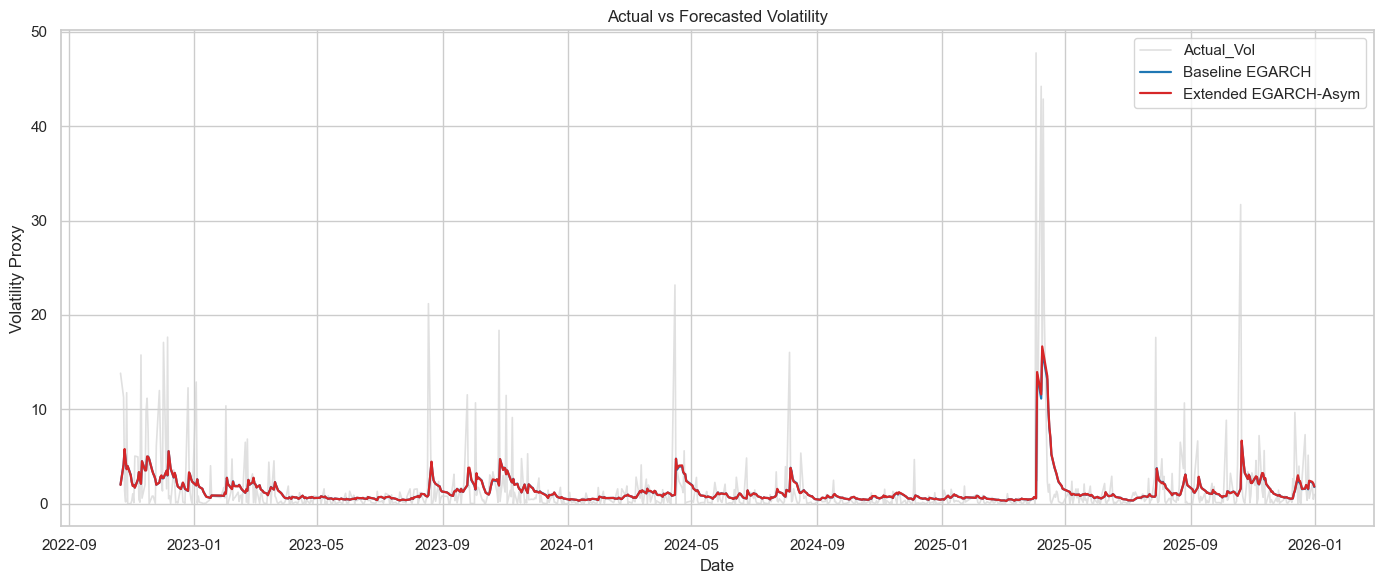

In [45]:
# 6) Plot actual vs forecasted volatility

plt.figure(figsize=(14, 6))
plt.plot(actual_vol.index, actual_vol_safe, color="lightgray", alpha=0.7, linewidth=1.2, label="Actual_Vol")
plt.plot(f_baseline_egarch.index, f_baseline_egarch, color="#1f77b4", linewidth=1.6, label="Baseline EGARCH")
plt.plot(f_extended_asym.index, f_extended_asym, color="#d62728", linewidth=1.6, label="Extended EGARCH-Asym")

plt.title("Actual vs Forecasted Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility Proxy")
plt.legend()
plt.tight_layout()
plt.show()

## Phase 4 - Forecast using Rolling Window (Bonus)

This bonus phase re-fits each model on a fixed-length rolling window and produces one-step-ahead variance forecasts across the test period.

- `ROLLING_MAX_STEPS = 120` runs a quick demo.
- Set `ROLLING_MAX_STEPS = None` to run the full test horizon.

In [51]:
# =========================
# Phase 4 setup and rolling helper
# =========================

ROLLING_WINDOW_SIZE = len(train)
ROLLING_MAX_STEPS = None
ROLLING_VERBOSE_EVERY = 30

rolling_data = model_df[["return", "target", "lag_SVI", "lag_SVI_pos", "lag_SVI_neg"]].dropna().copy()
rolling_test_index = rolling_data.index.intersection(test.index)

if ROLLING_MAX_STEPS is None:
    rolling_eval_index = rolling_test_index
else:
    rolling_eval_index = rolling_test_index[:ROLLING_MAX_STEPS]

print(f"Rolling window size: {ROLLING_WINDOW_SIZE}")
print(f"Rolling forecast steps: {len(rolling_eval_index)}")
print(f"Range: {rolling_eval_index.min().date()} -> {rolling_eval_index.max().date()}")


def _x_dict_from_row(row: pd.Series, cols: list[str]) -> dict:
    return {col: np.array([float(row[col])]) for col in cols}


def rolling_window_forecast(data: pd.DataFrame, eval_index: pd.Index, window_size: int, spec: dict, verbose_every: int = 50) -> pd.Series:
    """Rolling refit + one-step-ahead variance forecast."""
    preds = []
    idxs = []

    for i, date in enumerate(eval_index, start=1):
        end_loc = data.index.get_loc(date)
        start_loc = max(0, end_loc - window_size)
        train_win = data.iloc[start_loc:end_loc]

        y_win = train_win["return"]
        x_cols = spec.get("x_cols")
        x_win = train_win[x_cols] if x_cols else None

        am = arch_model(
            y=y_win,
            x=x_win,
            mean=spec["mean"],
            lags=0,
            vol=spec["vol"],
            p=spec["p"],
            o=spec.get("o", 0),
            q=spec["q"],
            dist="studentst",
            rescale=False,
        )
        res = am.fit(disp="off")

        if x_cols:
            x_next = _x_dict_from_row(data.loc[date], x_cols)
            fcast = res.forecast(horizon=1, reindex=False, x=x_next)
        else:
            fcast = res.forecast(horizon=1, reindex=False)

        preds.append(float(fcast.variance.iloc[-1, 0]))
        idxs.append(date)

        if verbose_every and i % verbose_every == 0:
            print(f"Processed {i}/{len(eval_index)} steps...")

    return pd.Series(preds, index=idxs, name="rolling_forecast_vol")

Rolling window size: 3191
Rolling forecast steps: 799
Range: 2022-10-21 -> 2025-12-31


In [52]:
# 1) Run rolling forecasts for 4 models

rolling_specs = {
    "Baseline GARCH(1,1)": {"mean": "Constant", "vol": "GARCH", "p": 1, "q": 1},
    "Baseline EGARCH(1,1)": {"mean": "Constant", "vol": "EGARCH", "p": 1, "o": 1, "q": 1},
    "Extended EGARCH-SVI": {"mean": "ARX", "vol": "EGARCH", "p": 1, "o": 1, "q": 1, "x_cols": ["lag_SVI"]},
    "Extended EGARCH-Asym": {
        "mean": "ARX",
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "x_cols": ["lag_SVI_pos", "lag_SVI_neg"],
    },
}

rolling_forecast_dict = {}
for model_name, spec in rolling_specs.items():
    print(f"Running rolling forecast: {model_name}")
    rolling_forecast_dict[model_name] = rolling_window_forecast(
        data=rolling_data,
        eval_index=rolling_eval_index,
        window_size=ROLLING_WINDOW_SIZE,
        spec=spec,
        verbose_every=ROLLING_VERBOSE_EVERY,
    )

print("Rolling forecasts completed.")

Running rolling forecast: Baseline GARCH(1,1)
Processed 30/799 steps...
Processed 60/799 steps...
Processed 90/799 steps...
Processed 120/799 steps...
Processed 150/799 steps...
Processed 180/799 steps...
Processed 210/799 steps...
Processed 240/799 steps...
Processed 270/799 steps...
Processed 300/799 steps...
Processed 330/799 steps...
Processed 360/799 steps...
Processed 390/799 steps...
Processed 420/799 steps...
Processed 450/799 steps...
Processed 480/799 steps...
Processed 510/799 steps...
Processed 540/799 steps...
Processed 570/799 steps...
Processed 600/799 steps...
Processed 630/799 steps...
Processed 660/799 steps...
Processed 690/799 steps...
Processed 720/799 steps...
Processed 750/799 steps...
Processed 780/799 steps...
Running rolling forecast: Baseline EGARCH(1,1)
Processed 30/799 steps...
Processed 60/799 steps...
Processed 90/799 steps...
Processed 120/799 steps...
Processed 150/799 steps...
Processed 180/799 steps...
Processed 210/799 steps...
Processed 240/799 step

In [53]:
# 2) Rolling-window evaluation table (RMSE / QLIKE)

rolling_actual_vol = rolling_data.loc[rolling_eval_index, "target"].clip(lower=EPS)

rolling_metric_rows = []
for model_name, pred in rolling_forecast_dict.items():
    metrics = evaluate_volatility_forecasts(rolling_actual_vol, pred)
    rolling_metric_rows.append({"Model": model_name, **metrics})

rolling_oos_cmp = pd.DataFrame(rolling_metric_rows).sort_values(["RMSE", "QLIKE"]).reset_index(drop=True)
rolling_oos_cmp["Best_RMSE"] = rolling_oos_cmp["RMSE"].eq(rolling_oos_cmp["RMSE"].min())
rolling_oos_cmp["Best_QLIKE"] = rolling_oos_cmp["QLIKE"].eq(rolling_oos_cmp["QLIKE"].min())

print("Rolling-window forecast comparison")
display(rolling_oos_cmp)

rolling_best_rmse_model = rolling_oos_cmp.loc[rolling_oos_cmp["RMSE"].idxmin(), "Model"]
rolling_best_qlike_model = rolling_oos_cmp.loc[rolling_oos_cmp["QLIKE"].idxmin(), "Model"]
print(f"Best rolling RMSE:  {rolling_best_rmse_model}")
print(f"Best rolling QLIKE: {rolling_best_qlike_model}")

Rolling-window forecast comparison


,Model,RMSE,QLIKE,Best_RMSE,Best_QLIKE
0,Extended EGARCH-Asym,3.621022,1.685393,True,True
1,Extended EGARCH-SVI,3.621896,1.686854,False,False
2,"Baseline EGARCH(1,1)",3.622811,1.687787,False,False
3,"Baseline GARCH(1,1)",3.768877,1.724146,False,False


Best rolling RMSE:  Extended EGARCH-Asym
Best rolling QLIKE: Extended EGARCH-Asym


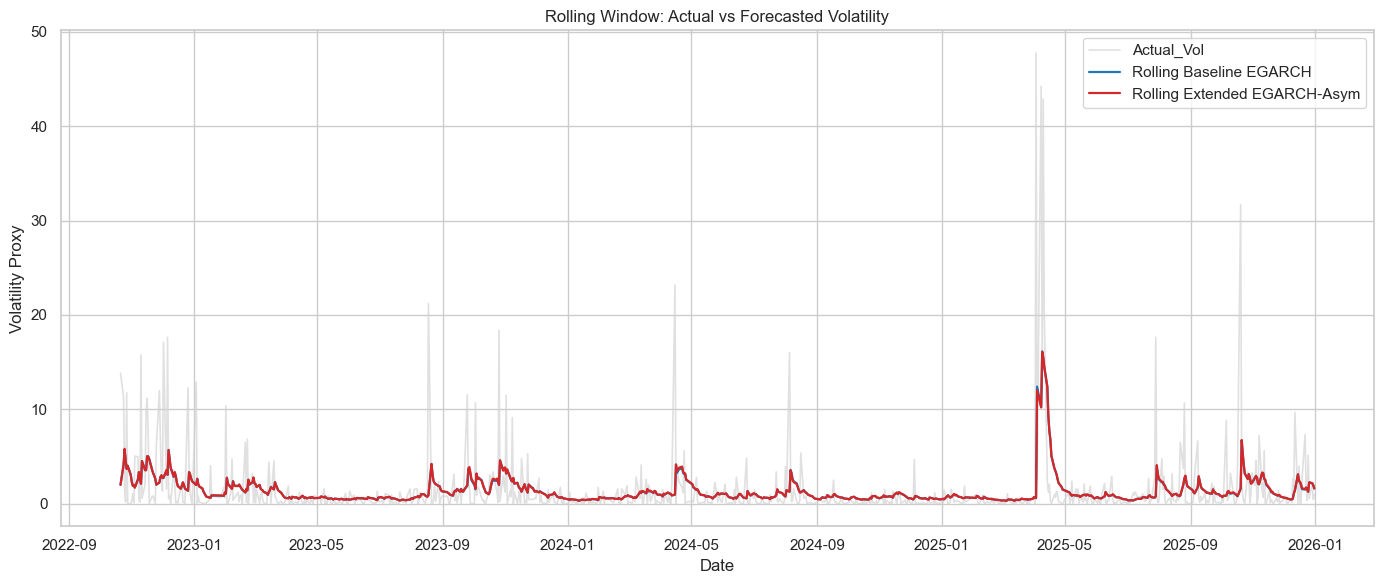

In [54]:
# 3) Bonus plot: rolling forecasts vs actual volatility

rolling_baseline = rolling_forecast_dict["Baseline EGARCH(1,1)"]
rolling_extended = rolling_forecast_dict["Extended EGARCH-Asym"]

plt.figure(figsize=(14, 6))
plt.plot(rolling_actual_vol.index, rolling_actual_vol, color="lightgray", alpha=0.7, linewidth=1.2, label="Actual_Vol")
plt.plot(rolling_baseline.index, rolling_baseline, color="#1f77b4", linewidth=1.6, label="Rolling Baseline EGARCH")
plt.plot(rolling_extended.index, rolling_extended, color="#d62728", linewidth=1.6, label="Rolling Extended EGARCH-Asym")

plt.title("Rolling Window: Actual vs Forecasted Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility Proxy")
plt.legend()
plt.tight_layout()
plt.show()